## **Atividade 02 B - PDI - Filtragem Espacial**

**Equipe: Felipe Rodrigues & Marcos Marques**

**Professor: Wagner Ferreira de Barros**

**Data: 02/05/2026**

### 1 Introdução

A filtragem espacial é uma técnica fundamental em PDI, utilizada para realçar características ou
remover imperfeições. Enquanto o filtro da média atua como um operador linear de passa-baixa,
suavizando transições bruscas, o filtro da mediana é um operador estatístico não-linear, extremamente
eficaz na preservação de bordas e na remoção de ruídos impulsivos.
O objetivo desta atividade é compreender a resposta de frequência e o comportamento estatístico
dos filtros da média e da mediana frente a diferentes tipos de degradação.

### 2 Preparacao
Usamos uma imagem do dataset e funcoes auxiliares para aplicar filtros e medir MSE/PSNR.

In [1]:
# Preparacao e funcoes auxiliares
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from numpy.lib.stride_tricks import sliding_window_view

# Escolhe uma imagem do dataset (ajuste se desejar um arquivo especifico)
def pick_image():
    root = Path("Dataset")
    preferred = [
        root / "stereo" / "cones" / "im0.png",
        root / "stereo" / "venus" / "im0.png",
        root / "stereo" / "tsukuba" / "im0.png",
        root / "stereo" / "teddy" / "im0.png",
    ]
    for p in preferred:
        if p.exists():
            return p
    for ext in ("*.png", "*.jpg", "*.jpeg", "*.bmp"):
        matches = list(root.rglob(ext))
        if matches:
            return matches[0]
    raise FileNotFoundError("Nao encontrei imagens no Dataset/")

image_path = pick_image()
img_rgb = np.array(Image.open(image_path).convert("RGB"), dtype=np.float32) / 255.0
img_gray = (img_rgb[..., 0] * 0.299 + img_rgb[..., 1] * 0.587 + img_rgb[..., 2] * 0.114).astype(np.float32)

def show_images(images, titles, cols=3, figsize=(12, 8)):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)
    for i, (im, title) in enumerate(zip(images, titles), 1):
        plt.subplot(rows, cols, i)
        if im.ndim == 2:
            plt.imshow(im, cmap="gray", vmin=0, vmax=1)
        else:
            plt.imshow(np.clip(im, 0, 1))
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()

def _mean_filter_single(img, k):
    pad = k // 2
    padded = np.pad(img, pad, mode="reflect")
    windows = sliding_window_view(padded, (k, k))
    return windows.mean(axis=(-2, -1))

def _median_filter_single(img, k):
    pad = k // 2
    padded = np.pad(img, pad, mode="reflect")
    windows = sliding_window_view(padded, (k, k))
    return np.median(windows, axis=(-2, -1))

def mean_filter(img, k):
    if img.ndim == 2:
        return _mean_filter_single(img, k)
    return np.stack([_mean_filter_single(img[..., c], k) for c in range(img.shape[2])], axis=2)

def median_filter(img, k):
    if img.ndim == 2:
        return _median_filter_single(img, k)
    return np.stack([_median_filter_single(img[..., c], k) for c in range(img.shape[2])], axis=2)

def add_salt_pepper(img, amount=0.05, salt_vs_pepper=0.5, seed=7):
    rng = np.random.default_rng(seed)
    out = img.copy()
    h, w = img.shape[:2]
    num = int(amount * h * w)
    coords = rng.choice(h * w, size=num, replace=False)
    ys, xs = np.unravel_index(coords, (h, w))
    num_salt = int(num * salt_vs_pepper)
    salt_idx = (ys[:num_salt], xs[:num_salt])
    pepper_idx = (ys[num_salt:], xs[num_salt:])
    if img.ndim == 2:
        out[salt_idx] = 1.0
        out[pepper_idx] = 0.0
    else:
        out[salt_idx[0], salt_idx[1], :] = 1.0
        out[pepper_idx[0], pepper_idx[1], :] = 0.0
    return out

def mse(a, b):
    return float(np.mean((a - b) ** 2))

def psnr(a, b, data_range=1.0):
    err = mse(a, b)
    if err == 0:
        return float("inf")
    return float(10 * np.log10((data_range ** 2) / err))

print("Imagem selecionada:", image_path)

Imagem selecionada: Dataset/stereo/teddy/imL.png


### 3 Suavizacao por Media

Media: kernels maiores tendem a suavizar mais e reduzir detalhes finos.


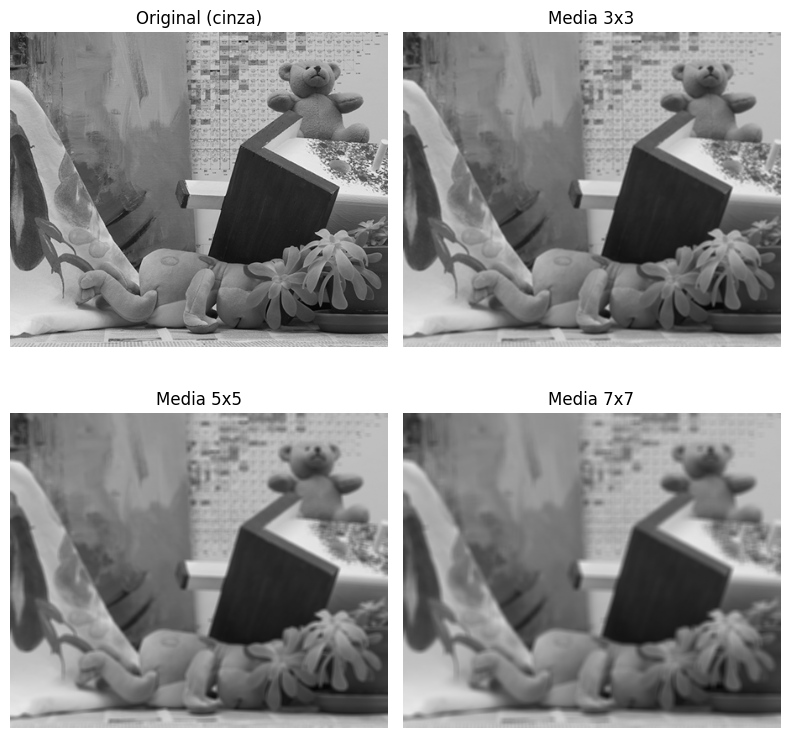

In [2]:
ks = [3, 5, 7]
mean_gray = [mean_filter(img_gray, k) for k in ks]

show_images(
    [img_gray] + mean_gray,
    ["Original (cinza)"] + [f"Media {k}x{k}" for k in ks],
    cols=2,
    figsize=(8, 8),
)

# Observacao rapida (preencha no texto da secao)
print("Media: kernels maiores tendem a suavizar mais e reduzir detalhes finos.")

### 4 Ruido Sal e Pimenta + Filtro da Mediana
Geramos ruido impulsivo e comparamos a recuperacao por mediana com MSE/PSNR.

Metricas (cinza) - Mediana vs Original:
{'kernel': '3x3', 'mse': 0.0009206522954627872, 'psnr': 30.35904359676821}
{'kernel': '5x5', 'mse': 0.0017262236215174198, 'psnr': 27.62902944831534}
{'kernel': '7x7', 'mse': 0.0023166232276707888, 'psnr': 26.351445935078566}


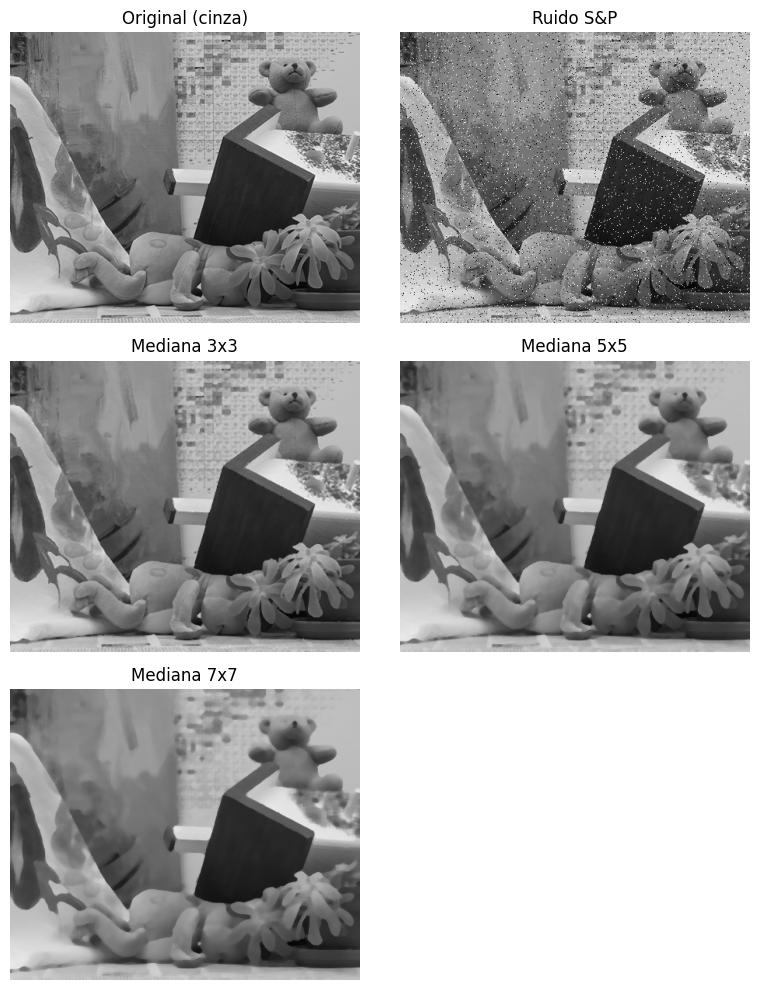

In [3]:
noisy_gray = add_salt_pepper(img_gray, amount=0.05, salt_vs_pepper=0.5, seed=7)
median_gray = [median_filter(noisy_gray, k) for k in ks]

show_images(
    [img_gray, noisy_gray] + median_gray,
    ["Original (cinza)", "Ruido S&P"] + [f"Mediana {k}x{k}" for k in ks],
    cols=2,
    figsize=(8, 10),
)

metrics = []
for k, img_f in zip(ks, median_gray):
    metrics.append({
        "kernel": f"{k}x{k}",
        "mse": mse(img_gray, img_f),
        "psnr": psnr(img_gray, img_f),
    })

print("Metricas (cinza) - Mediana vs Original:")
for row in metrics:
    print(row)

### 5 Combinacao de Filtros em Cascata
Comparamos media->mediana e mediana->media na imagem com ruido.

Metricas (cinza) - Cascata vs Original:
{'ordem': 'Media->Mediana', 'mse': 0.003062706906348467, 'psnr': 25.1389456213759}
{'ordem': 'Mediana->Media', 'mse': 0.002663210267201066, 'psnr': 25.745945435572423}


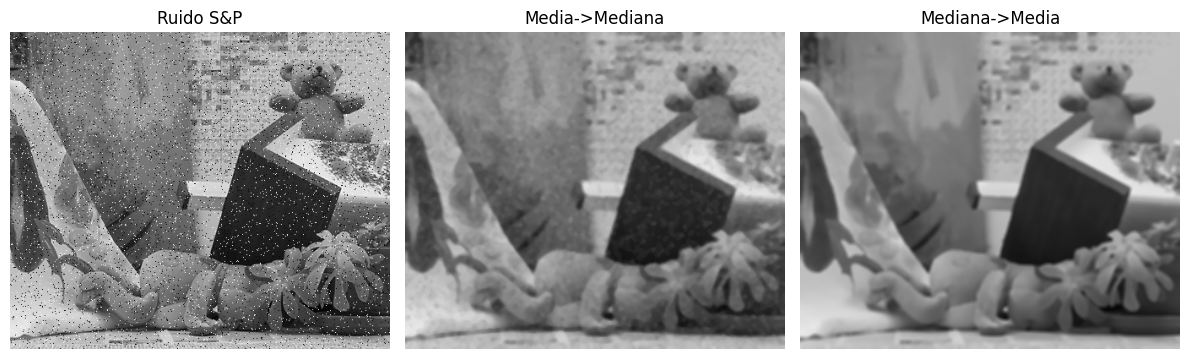

In [4]:
k_mean = 5
k_med = 5

mean_then_med = median_filter(mean_filter(noisy_gray, k_mean), k_med)
med_then_mean = mean_filter(median_filter(noisy_gray, k_med), k_mean)

show_images(
    [noisy_gray, mean_then_med, med_then_mean],
    ["Ruido S&P", "Media->Mediana", "Mediana->Media"],
    cols=3,
    figsize=(12, 4),
)

metrics_cascade = [
    {"ordem": "Media->Mediana", "mse": mse(img_gray, mean_then_med), "psnr": psnr(img_gray, mean_then_med)},
    {"ordem": "Mediana->Media", "mse": mse(img_gray, med_then_mean), "psnr": psnr(img_gray, med_then_mean)},
]

print("Metricas (cinza) - Cascata vs Original:")
for row in metrics_cascade:
    print(row)

### 6 Dominio de Cor
Comparamos filtros aplicados no RGB (canal a canal) e na versao em tons de cinza.

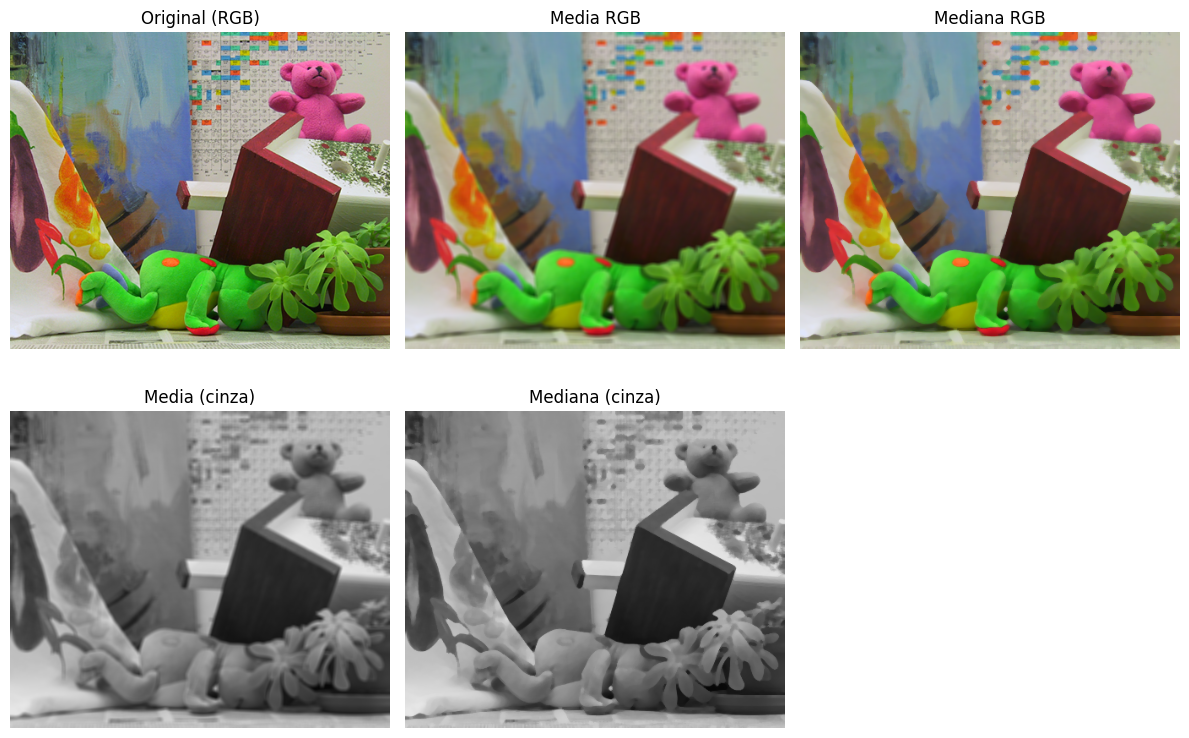

In [5]:
k = 5
mean_rgb = mean_filter(img_rgb, k)
median_rgb = median_filter(img_rgb, k)

# Filtra apenas a versao em cinza (referencia)
mean_gray_only = mean_filter(img_gray, k)
median_gray_only = median_filter(img_gray, k)
mean_gray_rgb = np.stack([mean_gray_only] * 3, axis=2)
median_gray_rgb = np.stack([median_gray_only] * 3, axis=2)

show_images(
    [img_rgb, mean_rgb, median_rgb, mean_gray_rgb, median_gray_rgb],
    ["Original (RGB)", "Media RGB", "Mediana RGB", "Media (cinza)", "Mediana (cinza)"],
    cols=3,
    figsize=(12, 8),
)

### 7 Analise Critica e Conclusao
**Suavizacao por media (kernel crescente)**
- Espera-se perda progressiva de nitidez: detalhes finos e bordas ficam mais suaves a medida que o kernel aumenta.
- O efeito de borramento e mais evidente em texturas e linhas finas.

**Ruido sal e pimenta + mediana**
- A mediana tende a remover pixels impulsivos mantendo bordas melhor do que a media.
- Comparação MSE/PSNR: kernels maiores podem reduzir mais o ruido, mas podem apagar detalhes.

**Cascata (media/mediana)**
- Em geral, aplicar mediana primeiro reduz ruido impulsivo antes da media suavizar o restante.
- A ordem inversa pode espalhar o ruido impulsivo, tornando-o menos tratavel pela mediana.

**Dominio de cor**
- Filtrar canal a canal preserva cor, mas pode gerar pequenos artefatos cromaticos se os canais divergem.
- Filtrar em cinza elimina informacao cromatica e pode reduzir detalhes coloridos.

**Conclusao**
- Use media quando o objetivo for suavizacao global de ruido suave (gaussiano) e quando perda de detalhe for aceitavel.
- Use mediana quando houver ruido impulsivo (sal e pimenta) ou quando preservar bordas for prioritario.
- Em imagens coloridas, prefira filtrar por canal para manter cores, a menos que a analise seja apenas de luminancia.